In [36]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification


Imports

In [37]:
import torch

from torch.utils.data import DataLoader

from src.data.dataset import WasteDataset
from src.data.transforms import (
    get_train_transforms,
    get_eval_transforms,
)

Define paths

In [38]:
DATASET_ROOT = PROJECT_ROOT / "data/raw/garbage-dataset"

TRAIN_MANIFEST = PROJECT_ROOT / "data/manifests/train.csv"
VAL_MANIFEST = PROJECT_ROOT / "data/manifests/val.csv"
TEST_MANIFEST = PROJECT_ROOT / "data/manifests/test.csv"

print(DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())

C:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\data\raw\garbage-dataset
Dataset exists: True


Create the training dataset

In [39]:
train_dataset = WasteDataset(
    manifest_path=TRAIN_MANIFEST,
    dataset_root=DATASET_ROOT,
    transform=get_train_transforms(),
)

print("Training images:", len(train_dataset))

print(
    "Class mapping:",
    train_dataset.class_to_idx
)

Training images: 13833
Class mapping: {'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


Critical improvement: share the class mapping

In [40]:
val_dataset = WasteDataset(
    manifest_path=VAL_MANIFEST,
    dataset_root=DATASET_ROOT,
    transform=get_eval_transforms(),
    class_to_idx=train_dataset.class_to_idx,
)

test_dataset = WasteDataset(
    manifest_path=TEST_MANIFEST,
    dataset_root=DATASET_ROOT,
    transform=get_eval_transforms(),
    class_to_idx=train_dataset.class_to_idx,
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

assert (
    train_dataset.class_to_idx
    == val_dataset.class_to_idx
    == test_dataset.class_to_idx
)

print("Class mappings are consistent.")

Train: 13833
Validation: 2964
Test: 2965
Class mappings are consistent.


Inspect a transformed sample

In [41]:
image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Class:", train_dataset.classes[label])

print(
    "Tensor dtype:",
    image.dtype
)

Image tensor shape: torch.Size([3, 224, 224])
Label: 0
Class: battery
Tensor dtype: torch.float32


Create DataLoaders

In [42]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Training batches: 433
Validation batches: 93


Load one batch

In [43]:
images, labels = next(
    iter(train_loader)
)

print(
    "Batch image shape:",
    images.shape
)

print(
    "Batch label shape:",
    labels.shape
)

print(
    "Image dtype:",
    images.dtype
)

print(
    "Label dtype:",
    labels.dtype
)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


Visually inspect preprocessing

In [44]:
import matplotlib.pyplot as plt

from src.data.transforms import (
    IMAGENET_MEAN,
    IMAGENET_STD,
)


def denormalize(image_tensor):

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    return image_tensor * std + mean

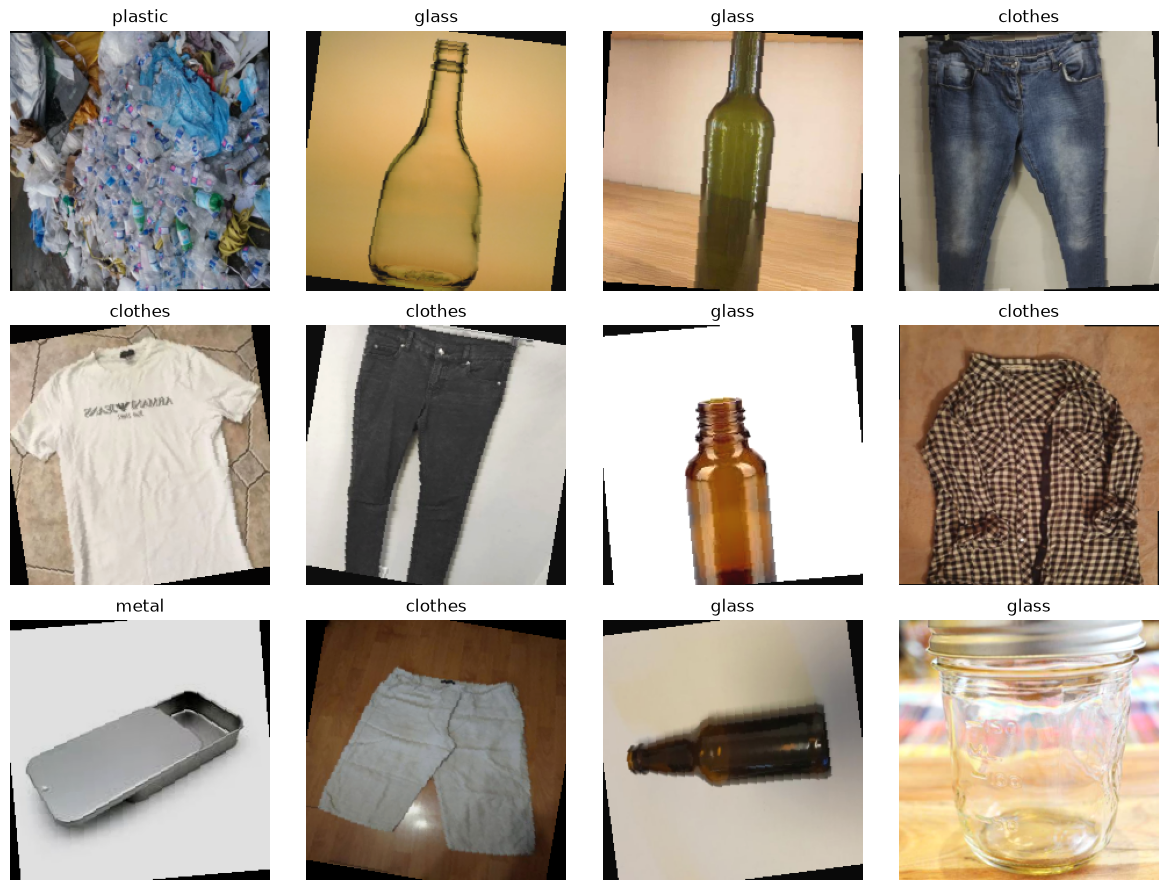

In [45]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9)
)

for i, ax in enumerate(axes.flat):

    image = denormalize(
        images[i].cpu()
    )

    image = image.clamp(0, 1)

    image = image.permute(
        1, 2, 0
    ).numpy()

    label = labels[i].item()

    ax.imshow(image)

    ax.set_title(
        train_dataset.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()